## ml_v4 
* y값은 ml_v2와 동일하게 설정
* 피처에 SPF지수 추가, 구글 미국 트렌드 성분 데이터 결합
* 이중 분류 모델로 확정

In [10]:
import pandas as pd
import numpy as np

df_product = pd.read_csv(r"C:\workspace\finalproject\data\sephora_products.csv")
df_ingredient = pd.read_csv(r"C:\workspace\finalproject\data\sephora_ingredients.csv")
df_sentiment = pd.read_csv(r"C:\workspace\finalproject\data\sephora_reviews_with_sentiment.csv")

print(f"상품: {df_product.shape}")
print(f"성분: {df_ingredient.shape}")
print(f"감성: {df_sentiment.shape}")

상품: (1838, 15)
성분: (1802, 118)
감성: (905553, 5)


In [11]:
import re
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

try:
    from lightgbm import LGBMClassifier
    from xgboost import XGBClassifier
except ImportError:
    pass

# ── Y값: PCA(y1 감성 + y2 로그리뷰수) → QuantileTransformer → 극단 30% 이진분류
agg = df_sentiment.groupby('product_id').agg(
    review_count  = ('rating', 'count'),
    avg_sentiment = ('sentiment_score', 'mean'),
).reset_index()

agg['y1'] = agg['avg_sentiment']
agg['y2'] = np.log1p(agg['review_count']) / np.log1p(agg['review_count'].max())

scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(agg[['y1', 'y2']])

pca = PCA(n_components=1)
y_pca = pca.fit_transform(y_scaled)
print(f"PCA 분산 설명력: {pca.explained_variance_ratio_[0]:.3f}")
print(f"PC1 로딩: y1(감성)={pca.components_[0,0]:.3f}  y2(리뷰수)={pca.components_[0,1]:.3f}")

qt = QuantileTransformer(output_distribution='uniform', random_state=42)
agg['y_pca'] = qt.fit_transform(y_pca)

# 극단 30% 이진분류
th_lo = agg['y_pca'].quantile(0.30)
th_hi = agg['y_pca'].quantile(0.70)
mask  = (agg['y_pca'] <= th_lo) | (agg['y_pca'] >= th_hi)
df_y  = agg[mask].copy()
df_y['target'] = (df_y['y_pca'] >= th_hi).astype(int)

print(f"\n학습 데이터: {len(df_y)}개  (긍정={df_y['target'].sum()}, 부정={len(df_y)-df_y['target'].sum()})")

PCA 분산 설명력: 0.587
PC1 로딩: y1(감성)=0.707  y2(리뷰수)=0.707

학습 데이터: 1082개  (긍정=541, 부정=541)


In [12]:
# ── 데이터 merge + 고정 피처 생성
df = df_y[['product_id', 'y_pca', 'target']].merge(
    df_product[['product_id', '상품명', '브랜드명', '공급가(USD)', '할인율(%)', '용량',
                '카테고리(대)', '카테고리(중)', 'target_category']],
    on='product_id', how='inner'
).merge(df_ingredient, on='product_id', how='left', suffixes=('', '_ing'))
df = df.drop(columns=[c for c in df.columns if c.endswith('_ing')])

# 성분 텍스트
ing_cols = [c for c in df.columns if c.startswith('성분_')]
df['ingredient_text']  = df[ing_cols].fillna('').agg(' '.join, axis=1).str.strip()
df['ingredient_count'] = df[ing_cols].notna().sum(axis=1)

# 용량(ml)
def extract_ml(s):
    if pd.isna(s): return np.nan
    m = re.search(r'([\d.]+)\s*ml', str(s), re.IGNORECASE)
    if m: return float(m.group(1))
    m = re.search(r'([\d.]+)\s*oz', str(s), re.IGNORECASE)
    if m: return float(m.group(1)) * 29.5735
    return np.nan
df['volume_ml'] = df['용량'].apply(extract_ml)

# SPF
def extract_spf(name):
    if pd.isna(name): return 0.0
    m = re.search(r'spf\s*(\d+)', str(name), re.IGNORECASE)
    return float(m.group(1)) if m else 0.0
df['spf_value'] = df['상품명'].apply(extract_spf)

# 가격대
price_d = pd.get_dummies(
    pd.cut(df['공급가(USD)'], bins=[0, 30, 71, 9999], labels=['low', 'mid', 'high']),
    prefix='price'
).astype(int)
df = pd.concat([df, price_d], axis=1)

# 카테고리(대) 원핫
cat_d = pd.get_dummies(df['target_category'], prefix='cat').astype(int)
df = pd.concat([df, cat_d], axis=1)

ing_lower = df['ingredient_text'].str.lower()

# K뷰티 대표 성분 (KOTRA 2024)
kbeauty_map = {
    'k_galactomyces': 'galactomyces',
    'k_bifida':       'bifida',
    'k_centella':     'centella',
    'k_ginseng':      'ginseng',
    'k_snail':        'snail',
    'k_beta_glucan':  'beta-glucan',
    'k_bakuchiol':    'bakuchiol',
    'k_pdrn':         'polydeoxyribonucleotide|pdrn',
    'k_propolis':     'propolis',
}
for feat, kw in kbeauty_map.items():
    df[feat] = ing_lower.str.contains(kw, regex=True).astype(int)
k_cols = list(kbeauty_map.keys())
df['k_beauty_ratio'] = df[k_cols].sum(axis=1) / len(k_cols)

# US 트렌드 성분 (Google Trends 기반, 이진)
gt_map = {
    'gt_ceramide':    'ceramide',    'gt_hyaluronic':  'hyaluronic',
    'gt_niacinamide': 'niacinamide', 'gt_retinol':     'retinol',
    'gt_vitamin_c':   'ascorbic',    'gt_azelaic':     'azelaic',
    'gt_benzoyl':     'benzoyl',     'gt_glycolic':    'glycolic',
    'gt_salicylic':   'salicylic',   'gt_tranexamic':  'tranexamic',
    'gt_centella':    'centella',    'gt_heartleaf':   'heartleaf',
    'gt_mugwort':     'mugwort',     'gt_panthenol':   'panthenol',
    'gt_snail':       'snail',       'gt_bakuchiol':   'bakuchiol',
    'gt_collagen':    'collagen',    'gt_glycerin':    'glycerin',
    'gt_peptide':     'peptide',     'gt_squalane':    'squalane',
}
for feat, kw in gt_map.items():
    df[feat] = ing_lower.str.contains(kw, regex=False).astype(int)
gt_cols = list(gt_map.keys())
df['us_trend_ratio'] = df[gt_cols].sum(axis=1) / len(gt_cols)

print(f"merge 후 shape: {df.shape}")
print(f"학습 데이터: {len(df)}개")

merge 후 shape: (1082, 169)
학습 데이터: 1082개


## 카테고리 중분류 EDA
> `카테고리(중)` 컬럼 탐색 → 희소 범주 파악 → y_pca 상관 검증

=== 카테고리(중) 고유값 및 분포 ===
카테고리(중)
Moisturizers    325
Treatments      263
Cleansers       209
Eye Care        112
Masks           108
Sunscreen        65

총 중분류 수: 6개
결측치: 0개

=== 대분류 × 중분류 교차 ===
 카테고리(대)      카테고리(중)  count
Skincare    Cleansers    209
Skincare     Eye Care    112
Skincare        Masks    108
Skincare Moisturizers    325
Skincare    Sunscreen     65
Skincare   Treatments    263


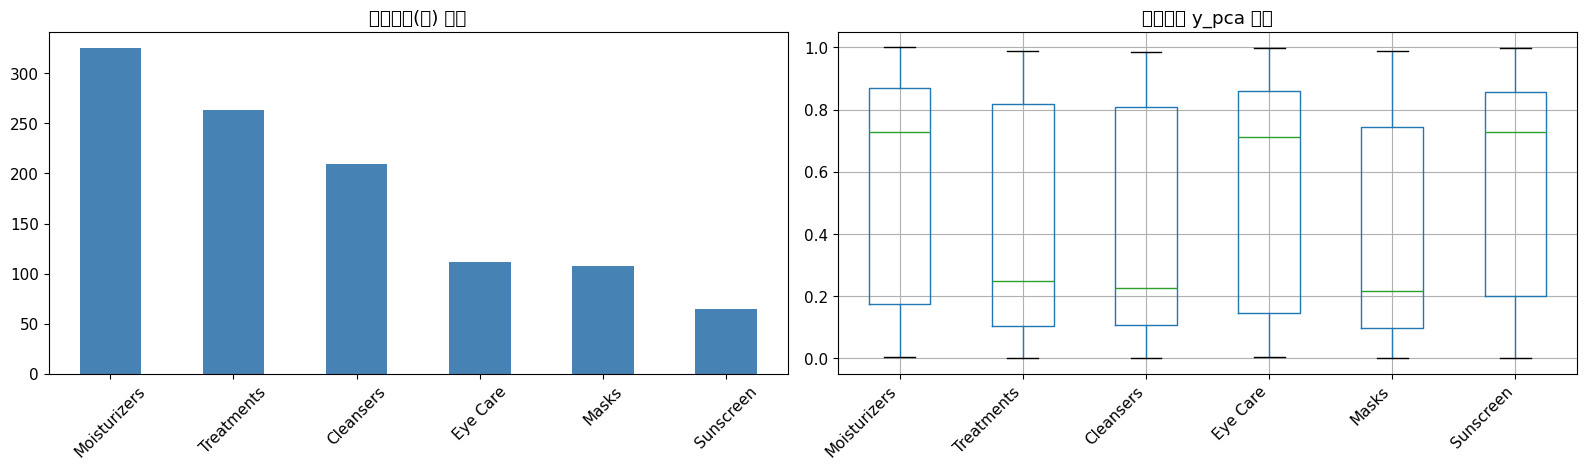

In [13]:
# 1. 카테고리 중분류 고유값 + 분포
print("=== 카테고리(중) 고유값 및 분포 ===")
mid_counts = df['카테고리(중)'].value_counts()
print(mid_counts.to_string())
print(f"\n총 중분류 수: {df['카테고리(중)'].nunique()}개")
print(f"결측치: {df['카테고리(중)'].isna().sum()}개")

# 대분류 × 중분류 교차표
print("\n=== 대분류 × 중분류 교차 ===")
cross = df.groupby(['카테고리(대)', '카테고리(중)']).size().reset_index(name='count')
print(cross.to_string(index=False))

# 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
mid_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('카테고리(중) 분포')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

# 중분류별 y_pca 박스플롯
order = mid_counts.index.tolist()
df.boxplot(column='y_pca', by='카테고리(중)', ax=axes[1], 
           positions=range(len(order)), rot=45)
axes[1].set_xticklabels(order, rotation=45, ha='right')
axes[1].set_title('중분류별 y_pca 분포')
axes[1].set_xlabel('')
plt.suptitle('')
plt.tight_layout()
plt.show()

In [14]:
# 2. 중분류별 y_pca 상관 검증 (ANOVA + Pearson)
# 희소 범주(n<10) 원핫인코딩 시 노이즈 → 병합 기준 확인

print("=== 중분류별 샘플 수 및 y_pca 평균 ===")
mid_stat = df.groupby('카테고리(중)')['y_pca'].agg(['count', 'mean', 'std']).round(3)
mid_stat.columns = ['count', 'y_pca_mean', 'y_pca_std']
mid_stat = mid_stat.sort_values('y_pca_mean', ascending=False)
print(mid_stat.to_string())

# 원핫인코딩 → Pearson 상관
mid_dummies = pd.get_dummies(df['카테고리(중)'], prefix='mid').astype(int)

results = []
for col in mid_dummies.columns:
    r, p = stats.pearsonr(mid_dummies[col], df['y_pca'])
    n = mid_dummies[col].sum()
    results.append({'feature': col, 'n': n, 'corr': r, 'abs_corr': abs(r), 'p_value': p})

mid_corr = pd.DataFrame(results).sort_values('abs_corr', ascending=False)
print("\n=== 중분류 원핫 → y_pca Pearson 상관 ===")
print(mid_corr.to_string(index=False))

sig = mid_corr[(mid_corr['abs_corr'] > 0.05) & (mid_corr['p_value'] < 0.05)]
print(f"\n유의미 (|r|>0.05, p<0.05): {len(sig)}개")
print(sig.to_string(index=False))

=== 중분류별 샘플 수 및 y_pca 평균 ===
              count  y_pca_mean  y_pca_std
카테고리(중)                                   
Treatments      263       0.550      0.344
Cleansers       209       0.537      0.359
Moisturizers    325       0.518      0.365
Eye Care        112       0.431      0.362
Masks           108       0.411      0.362
Sunscreen        65       0.356      0.340

=== 중분류 원핫 → y_pca Pearson 상관 ===
         feature   n      corr  abs_corr  p_value
   mid_Sunscreen  65 -0.100682  0.100682 0.000912
       mid_Masks 108 -0.082286  0.082286 0.006766
  mid_Treatments 263  0.079227  0.079227 0.009129
    mid_Eye Care 112 -0.064810  0.064810 0.033037
   mid_Cleansers 209  0.049544  0.049544 0.103354
mid_Moisturizers 325  0.032265  0.032265 0.288984

유의미 (|r|>0.05, p<0.05): 4개
       feature   n      corr  abs_corr  p_value
 mid_Sunscreen  65 -0.100682  0.100682 0.000912
     mid_Masks 108 -0.082286  0.082286 0.006766
mid_Treatments 263  0.079227  0.079227 0.009129
  mid_Eye Care 112 -0.

## 모델 학습 — 고정 피처 기준 베이스라인

In [ ]:
# 고정 피처 구성
fixed_cols = (
    ['price_low', 'price_mid', 'price_high']          # 가격대
    + ['volume_ml', 'spf_value']                       # 용량, SPF
    + [c for c in df.columns if c.startswith('cat_')]  # 카테고리(대)
    + k_cols + ['k_beauty_ratio']                      # K뷰티 성분
    + gt_cols + ['us_trend_ratio']                     # US트렌드 성분(GT)
)
fixed_cols = [c for c in fixed_cols if c in df.columns]

X_base = df[fixed_cols].fillna(0).astype(float)

tfidf = TfidfVectorizer(max_features=50, token_pattern=r"[A-Za-z][A-Za-z0-9\-\s]+")
X_tfidf = tfidf.fit_transform(df['ingredient_text'].fillna(''))

X = np.hstack([X_base.values, X_tfidf.toarray()])
y = df['target'].values

print(f"피처 수: {X_base.shape[1]} (structured) + 50 (TF-IDF) = {X.shape[1]} 총")
print(f"샘플 수: {X.shape[0]}  |  클래스 분포: {dict(zip(*np.unique(y, return_counts=True)))}")

# 5-Fold CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'LightGBM':           LGBMClassifier(random_state=42, verbose=-1),
    'XGBoost':            XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
}

print("\n=== 5-Fold CV 결과 ===")
cv_results = {}
for name, model in models.items():
    cv = cross_validate(model, X, y, cv=skf,
                        scoring=['accuracy', 'roc_auc'],
                        return_train_score=False)
    acc = cv['test_accuracy'].mean()
    auc = cv['test_roc_auc'].mean()
    cv_results[name] = {'accuracy': acc, 'roc_auc': auc}
    print(f"  {name:22s}  Accuracy={acc:.4f}  ROC-AUC={auc:.4f}")

best = max(cv_results, key=lambda k: cv_results[k]['roc_auc'])
print(f"\n최고 모델: {best}  AUC={cv_results[best]['roc_auc']:.4f}")
print(f"ml_v3 베이스라인: 0.7159  →  변화: {cv_results[best]['roc_auc'] - 0.7159:+.4f}")

피처 수: 40 (structured) + 50 (TF-IDF) = 90 총
샘플 수: 1082  |  클래스 분포: {0: 541, 1: 541}

=== 5-Fold CV 결과 ===
  LogisticRegression      Accuracy=0.6580  ROC-AUC=0.6985
  RandomForest            Accuracy=0.6544  ROC-AUC=0.7120
  LightGBM                Accuracy=0.6765  ROC-AUC=0.7214
  XGBoost                 Accuracy=0.6488  ROC-AUC=0.7062

최고 모델: LightGBM  AUC=0.7214
ml_v3 베이스라인: 0.7159  →  변화: +0.0055


=== Feature Importance (상위 30) ===
        feature  importance
      volume_ml         787
 us_trend_ratio         361
     tfidf_aqua         239
    tfidf_water         233
      spf_value         113
      price_mid         105
     gt_peptide          86
    gt_squalane          84
     price_high          83
      price_low          82
 gt_niacinamide          71
     tfidf_leaf          68
 k_beauty_ratio          62
   cat_skincare          59
    gt_glycerin          50
      cat_masks          48
    gt_ceramide          42
   gt_vitamin_c          40
   gt_salicylic          39
  gt_hyaluronic          38
  cat_cleansing          36
    tfidf_aqua           35
   gt_panthenol          33
     k_centella          30
tfidf_extrait d          26
   tfidf_ppg-14          21
    gt_glycolic          20
      k_ginseng          17
    gt_collagen          15
  k_beta_glucan          15

=== Feature Importance (하위 — importance=0) ===
importance=0인 피처: 51개
['tfidf_ppg-10', 'tfidf_sal

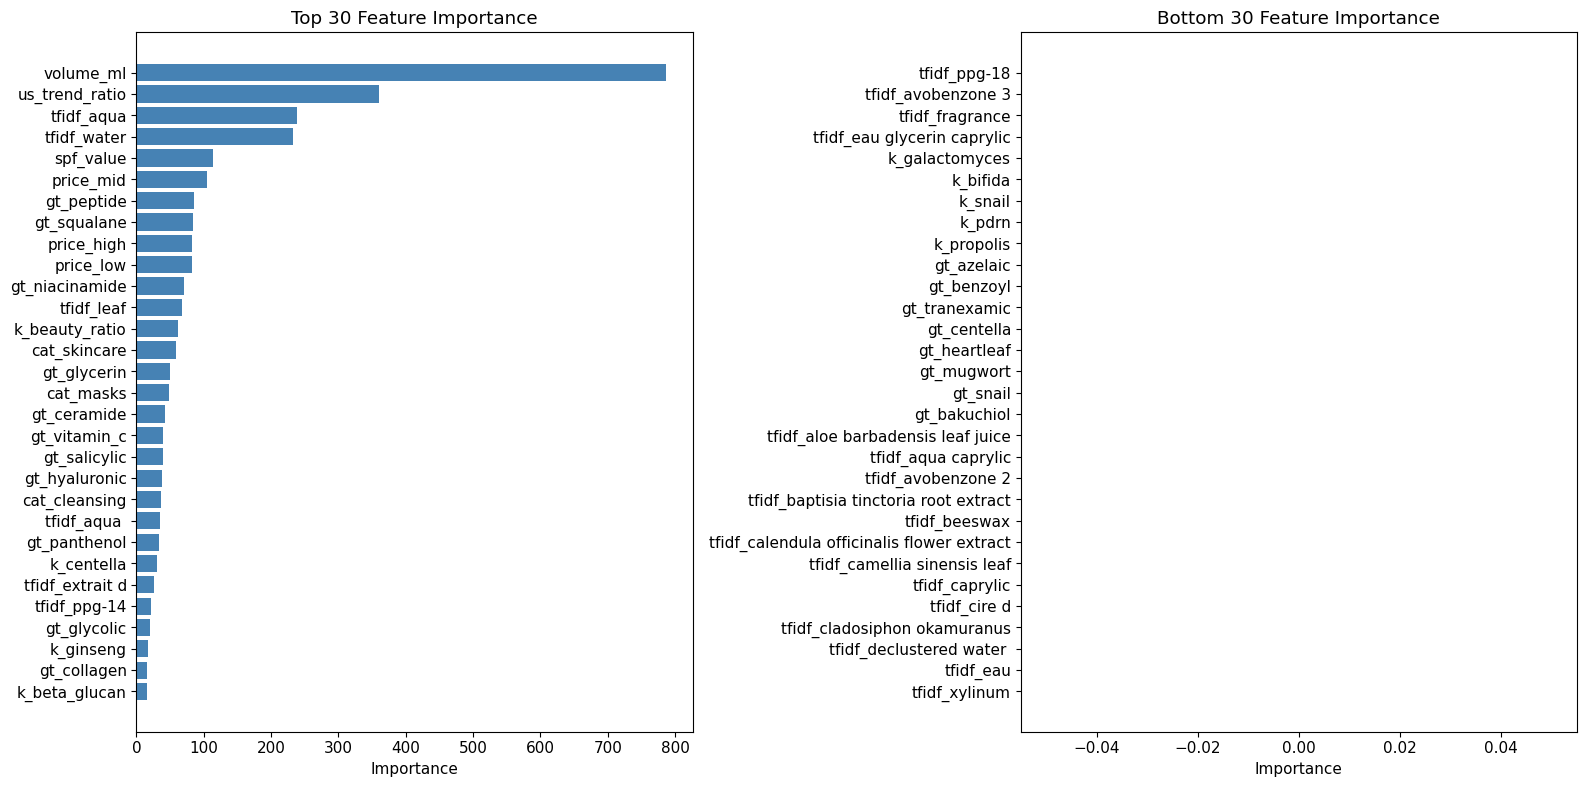

In [19]:
# LightGBM Feature Importance (baseline 기준)
X_base_vals = df[fixed_cols].fillna(0).astype(float).values
X_tfidf_arr = tfidf.transform(df['ingredient_text'].fillna(''))
X_bl = np.hstack([X_base_vals, X_tfidf_arr.toarray()])

feat_names = fixed_cols + [f'tfidf_{w}' for w in tfidf.get_feature_names_out()]

lgbm_fit = LGBMClassifier(random_state=42, verbose=-1)
lgbm_fit.fit(X_bl, y)

imp_df = pd.DataFrame({
    'feature':    feat_names,
    'importance': lgbm_fit.feature_importances_,
}).sort_values('importance', ascending=False)

# 전체 출력
print("=== Feature Importance (상위 30) ===")
print(imp_df.head(30).to_string(index=False))

print("\n=== Feature Importance (하위 — importance=0) ===")
zero = imp_df[imp_df['importance'] == 0]
print(f"importance=0인 피처: {len(zero)}개")
print(zero['feature'].tolist())

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 상위 30
top30 = imp_df.head(30)
axes[0].barh(top30['feature'][::-1], top30['importance'][::-1], color='steelblue')
axes[0].set_title('Top 30 Feature Importance')
axes[0].set_xlabel('Importance')

# 하위 30
bot30 = imp_df.tail(30)
axes[1].barh(bot30['feature'][::-1], bot30['importance'][::-1], color='tomato')
axes[1].set_title('Bottom 30 Feature Importance')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

In [20]:
# importance=0 피처 제거 후 AUC 비교
keep_mask = imp_df[imp_df['importance'] > 0]['feature'].tolist()

# structured / tfidf 분리
keep_struct = [f for f in keep_mask if not f.startswith('tfidf_')]
keep_tfidf  = [f.replace('tfidf_', '') for f in keep_mask if f.startswith('tfidf_')]

X_struct_pruned = df[keep_struct].fillna(0).astype(float).values
X_tfidf_pruned  = tfidf.transform(df['ingredient_text'].fillna(''))
# tfidf 컬럼 필터
tfidf_vocab = tfidf.get_feature_names_out()
tfidf_keep_idx = [i for i, w in enumerate(tfidf_vocab) if w in keep_tfidf]
X_tfidf_pruned  = X_tfidf_pruned.toarray()[:, tfidf_keep_idx]

X_pruned = np.hstack([X_struct_pruned, X_tfidf_pruned])

print(f"피처 수: {X_bl.shape[1]} → {X_pruned.shape[1]} ({X_bl.shape[1]-X_pruned.shape[1]}개 제거)")

lgbm = LGBMClassifier(random_state=42, verbose=-1)
cv_bl = cross_validate(lgbm, X_bl,     y, cv=skf, scoring=['roc_auc'])
cv_pr = cross_validate(lgbm, X_pruned, y, cv=skf, scoring=['roc_auc'])

auc_bl = cv_bl['test_roc_auc'].mean()
auc_pr = cv_pr['test_roc_auc'].mean()

print(f"\nbaseline  AUC={auc_bl:.4f}")
print(f"정제 후   AUC={auc_pr:.4f}  (변화: {auc_pr-auc_bl:+.4f})")

피처 수: 90 → 39 (51개 제거)

baseline  AUC=0.7214
정제 후   AUC=0.7214  (변화: +0.0000)


## 하이퍼파라미터 튜닝 — LightGBM (RandomizedSearchCV)

In [23]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators':      [100, 200, 300, 500],
    'learning_rate':     [0.01, 0.05, 0.1, 0.2],
    'max_depth':         [-1, 4, 6, 8],
    'num_leaves':        [15, 31, 63, 127],
    'min_child_samples': [10, 20, 30, 50],
    'subsample':         [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree':  [0.6, 0.7, 0.8, 1.0],
    'reg_alpha':         [0, 0.01, 0.1, 1.0],
    'reg_lambda':        [0, 0.01, 0.1, 1.0],
}

search = RandomizedSearchCV(
    LGBMClassifier(random_state=42, verbose=-1),
    param_distributions=param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=skf,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
search.fit(X_pruned, y)

print(f"\n최적 AUC : {search.best_score_:.4f}  (baseline 대비 {search.best_score_-0.7214:+.4f})")
print("최적 파라미터:")
for k, v in search.best_params_.items():
    print(f"  {k:22s}: {v}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

최적 AUC : 0.7326  (baseline 대비 +0.0112)
최적 파라미터:
  subsample             : 0.7
  reg_lambda            : 0.01
  reg_alpha             : 0.01
  num_leaves            : 63
  n_estimators          : 300
  min_child_samples     : 20
  max_depth             : -1
  learning_rate         : 0.01
  colsample_bytree      : 0.7


In [24]:
from sklearn.model_selection import GridSearchCV

# 영향력 큰 파라미터만 근방 미세 탐색 (3^5 = 243조합 × 5fold)
# reg_alpha/lambda/subsample/colsample은 best값 고정
param_grid = {
    'n_estimators':      [200, 300, 400],
    'learning_rate':     [0.005, 0.01, 0.02],
    'num_leaves':        [47, 63, 79],
    'min_child_samples': [15, 20, 25],
    'max_depth':         [-1, 6, 8],
}

grid = GridSearchCV(
    LGBMClassifier(
        random_state=42, verbose=-1,
        subsample=0.7, colsample_bytree=0.7,
        reg_alpha=0.01, reg_lambda=0.01,
    ),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=skf,
    n_jobs=-1,
    verbose=1,
)
grid.fit(X_pruned, y)

print(f"\n최적 AUC : {grid.best_score_:.4f}  (RandomizedSearch 대비 {grid.best_score_-0.7326:+.4f})")
print("최적 파라미터:")
for k, v in grid.best_params_.items():
    print(f"  {k:22s}: {v}")

Fitting 5 folds for each of 243 candidates, totalling 1215 fits

최적 AUC : 0.7357  (RandomizedSearch 대비 +0.0031)
최적 파라미터:
  learning_rate         : 0.02
  max_depth             : 8
  min_child_samples     : 20
  n_estimators          : 200
  num_leaves            : 47


=== 최종 모델 (GridSearch 최적) ===
OOF ROC-AUC: 0.7336

              precision    recall  f1-score   support

    하위30%(0)       0.68      0.67      0.68       541
    상위30%(1)       0.68      0.69      0.68       541

    accuracy                           0.68      1082
   macro avg       0.68      0.68      0.68      1082
weighted avg       0.68      0.68      0.68      1082



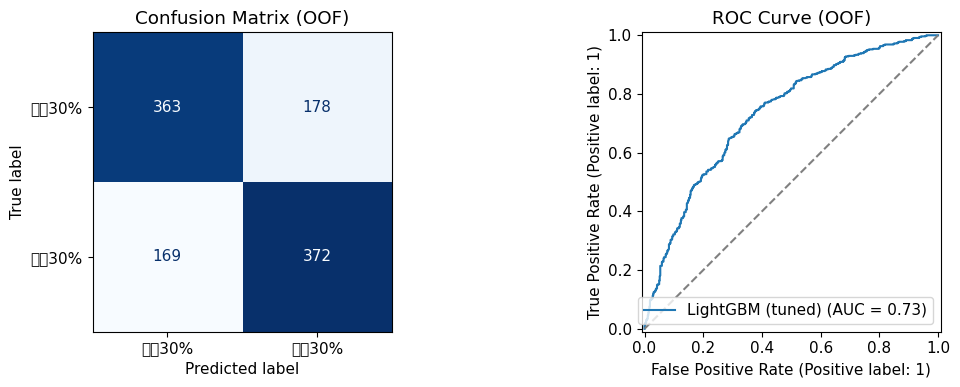

In [25]:
# 최종 모델 — Confusion Matrix + ROC Curve
best_lgbm = grid.best_estimator_

y_pred = cross_val_predict(best_lgbm, X_pruned, y, cv=skf, method='predict')
y_prob = cross_val_predict(best_lgbm, X_pruned, y, cv=skf, method='predict_proba')[:, 1]

from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

print(f"=== 최종 모델 (GridSearch 최적) ===")
print(f"OOF ROC-AUC: {roc_auc_score(y, y_prob):.4f}")
print()
print(classification_report(y, y_pred, target_names=['하위30%(0)', '상위30%(1)']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay(confusion_matrix(y, y_pred),
                       display_labels=['하위30%', '상위30%']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (OOF)')

RocCurveDisplay.from_predictions(y, y_prob, ax=axes[1], name='LightGBM (tuned)')
axes[1].plot([0,1],[0,1],'--', color='gray')
axes[1].set_title('ROC Curve (OOF)')

plt.tight_layout()
plt.show()

## 모델 저장 + predict_trend_score() 함수

In [30]:
import pickle, os

SAVE_DIR = r"C:\workspace\finalproject\data\model_output"
os.makedirs(SAVE_DIR, exist_ok=True)

# 전체 데이터로 최종 모델 학습
lgbm_final = LGBMClassifier(**best_params)
lgbm_final.fit(X_pruned, y)

# 저장 객체
artifacts = {
    'model':           lgbm_final,   # 학습된 LightGBM
    'tfidf':           tfidf,         # 성분 TF-IDF (max_features=50)
    'keep_struct':     keep_struct,   # 구조적 피처 컬럼명 리스트
    'tfidf_keep_idx':  tfidf_keep_idx,# TF-IDF 유효 컬럼 인덱스
    'gt_map':          gt_map,        # GT 성분 키워드 매핑
    'kbeauty_map':     kbeauty_map,   # K뷰티 성분 키워드 매핑
    'best_params':     best_params,
}

save_path = os.path.join(SAVE_DIR, 'lgbm_v4.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(artifacts, f)

print(f"저장 완료: {save_path}")
print(f"구조적 피처: {len(keep_struct)}개")
print(f"TF-IDF 유효 컬럼: {len(tfidf_keep_idx)}개")
print(f"총 피처: {X_pruned.shape[1]}개")

저장 완료: C:\workspace\finalproject\data\model_output\lgbm_v4.pkl
구조적 피처: 27개
TF-IDF 유효 컬럼: 12개
총 피처: 39개


In [31]:
def predict_trend_score(
    product_name: str,
    price_usd: float,
    volume_ml: float,
    ingredient_list: list,        # 성분명 리스트 (영문)
    category: str,                # 'skincare' / 'cleansing' / 'masks' / 'suncare'
    artifacts: dict = artifacts,
) -> dict:
    """
    한국 신규 상품 → 미국 트렌드 적합도 점수 (0~100) 반환
    """
    model         = artifacts['model']
    tfidf_        = artifacts['tfidf']
    keep_struct_  = artifacts['keep_struct']
    tfidf_idx_    = artifacts['tfidf_keep_idx']
    gt_map_       = artifacts['gt_map']
    kbeauty_map_  = artifacts['kbeauty_map']

    ingredient_text = ' '.join(ingredient_list)
    ing_lower = ingredient_text.lower()

    # 구조적 피처 딕셔너리 생성
    feat = {}

    # 가격대
    feat['price_low']  = int(price_usd <= 30)
    feat['price_mid']  = int(30 < price_usd <= 71)
    feat['price_high'] = int(price_usd > 71)

    # 용량, SPF
    feat['volume_ml'] = volume_ml if volume_ml else 0.0
    spf_m = re.search(r'spf\s*(\d+)', product_name, re.IGNORECASE)
    feat['spf_value'] = float(spf_m.group(1)) if spf_m else 0.0

    # 카테고리(대)
    for cat in ['skincare', 'cleansing', 'masks', 'suncare']:
        feat[f'cat_{cat}'] = int(category.lower() == cat)

    # K뷰티 성분
    k_vals = {}
    for f, kw in kbeauty_map_.items():
        v = int(bool(re.search(kw, ing_lower)))
        feat[f] = v
        k_vals[f] = v
    feat['k_beauty_ratio'] = sum(k_vals.values()) / len(k_vals)

    # GT 성분 이진
    gt_vals = {}
    for f, kw in gt_map_.items():
        v = int(kw in ing_lower)
        feat[f] = v
        gt_vals[f] = v
    feat['us_trend_ratio'] = sum(gt_vals.values()) / len(gt_vals)

    # keep_struct 순서로 정렬
    row = np.array([[feat.get(c, 0.0) for c in keep_struct_]], dtype=float)

    # TF-IDF
    tfidf_vec = tfidf_.transform([ingredient_text]).toarray()[:, tfidf_idx_]

    X_new = np.hstack([row, tfidf_vec])
    prob  = model.predict_proba(X_new)[0][1]
    score = round(prob * 100, 1)

    return {
        'trend_score':    score,
        'prediction':     '트렌드 적합' if prob >= 0.5 else '트렌드 비적합',
        'probability':    round(prob, 4),
        'gt_ingredients': [k for k, v in gt_vals.items() if v == 1],
        'k_ingredients':  [k for k, v in k_vals.items() if v == 1],
    }


# ── 테스트: 샘플 한국 상품
result = predict_trend_score(
    product_name   = "Niacinamide 10% + Zinc 1% Serum",
    price_usd      = 12.0,
    volume_ml      = 30.0,
    ingredient_list= ["Niacinamide", "Zinc PCA", "Glycerin", "Hyaluronic Acid"],
    category       = "skincare",
)
print("=== 예측 결과 ===")
for k, v in result.items():
    print(f"  {k}: {v}")

=== 예측 결과 ===
  trend_score: 51.7
  prediction: 트렌드 적합
  probability: 0.5169
  gt_ingredients: ['gt_hyaluronic', 'gt_niacinamide', 'gt_glycerin']
  k_ingredients: []
